# Eddy-equal ESP population composites with uncertainty
Run after notebook 00. Every daily field is evaluated before averaging. Average days within each eddy/group, then average eddy means equally. Profiles share a single shallow reference and exact depth catalogue. Planetary axes are east/north; topographic axes are onshore/alongshore. Their axes have different meanings, so do not subtract these fields as a like-for-like geographic contrast.

These are reconstructed horizontal velocities through a three-dimensional volume, not vertical velocity or hydrography. Ocean masking describes actual spatial support. Each pixel reports its own contributing eddies. Centrelines use the matched complete-profile sample.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
import seacofs_tilt_tools as tilt
import population_tools as pop
pd.set_option('display.max_columns', 60)


In [2]:
OUTPUT_ROOT = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites')
RUN_PATH = None  # set an explicit prior run directory to reproduce it
run = Path(RUN_PATH) if RUN_PATH else Path((OUTPUT_ROOT/'latest_run.txt').read_text().strip())
provenance = json.loads((run/'provenance.json').read_text())
config = provenance['config']
for filename, saved in provenance['sources'].items():
    stat = Path(filename).stat()
    if stat.st_size != saved['size'] or stat.st_mtime_ns != saved['mtime_ns']:
        raise RuntimeError(f'Input changed since audit: {filename}; rerun notebook 00')
import hashlib
if hashlib.sha256(Path(pop.__file__).read_bytes()).hexdigest() != provenance['implementation_sha256']:
    raise RuntimeError('Implementation changed since audit; rerun notebook 00')
selected = pd.read_parquet(run/'selected.parquet')
profiles = pd.read_parquet(run/'profiles.parquet')
depths = np.array(config['depths'])
if config['grid_step'] <= 0 or config['half_width'] <= 0:
    raise ValueError('Grid step and half width must be positive')
coordinate = np.arange(-config['half_width'], config['half_width']+config['grid_step']/2, config['grid_step'])
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
# Load the exact requested ESP source, avoiding a stale unrelated `functions` module.
import importlib.util
esp_file = Path(config['esp_root'])/'functions.py'
if str(esp_file.parent) not in sys.path: sys.path.insert(0, str(esp_file.parent))
spec = importlib.util.spec_from_file_location('population_esp_backend', esp_file)
esp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(esp)
(run/'esp_backend_sha256.txt').write_text(hashlib.sha256(esp_file.read_bytes()).hexdigest())
print('Run:', run)
print('Reconstructing', len(selected), 'days across', selected.Eddy.nunique(), 'eddies')


Run: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites/39f937013b2719bf
Reconstructing 53807 days across 2724 eddies


In [3]:
# Streaming accumulation: only one daily field and one eddy accumulator are live.
# Rerunning rebuilds member files; it never silently resumes stale reconstructions.
manifest = pop.build_members(selected, profiles, depths, coordinate, grid, esp.model_uv_at_xy,
                             run/'members', units=config['units'], mask_ocean=config['mask_ocean'])
display(manifest.groupby('group').agg(eddies=('Eddy','nunique'), days=('days','sum')))


Reconstructed 25 eddy/group members
Reconstructed 50 eddy/group members
Reconstructed 75 eddy/group members
Reconstructed 100 eddy/group members
Reconstructed 125 eddy/group members
Reconstructed 150 eddy/group members
Reconstructed 175 eddy/group members
Reconstructed 200 eddy/group members
Reconstructed 225 eddy/group members
Reconstructed 250 eddy/group members
Reconstructed 275 eddy/group members
Reconstructed 300 eddy/group members
Reconstructed 325 eddy/group members
Reconstructed 350 eddy/group members
Reconstructed 375 eddy/group members
Reconstructed 400 eddy/group members
Reconstructed 425 eddy/group members
Reconstructed 450 eddy/group members
Reconstructed 475 eddy/group members
Reconstructed 500 eddy/group members
Reconstructed 525 eddy/group members
Reconstructed 550 eddy/group members
Reconstructed 575 eddy/group members
Reconstructed 600 eddy/group members
Reconstructed 625 eddy/group members
Reconstructed 650 eddy/group members
Reconstructed 675 eddy/group members
Reco

,eddies,days
group,,
AE_Planetary,382,3926
AE_Topographic,1190,19353
CE_Planetary,317,1528
CE_Topographic,1407,29000


## Eddy-cluster bootstrap
Pointwise 95% percentile intervals resample eddy IDs, not days. Global draws preserve the dependence of members shared between groups. Intervals quantify between-eddy sampling uncertainty conditional on selection and fitted parameters; they do not include ESP fitting error or cache uncertainty. Spatially correlated neighbouring eddies can make these intervals optimistic.

The default support threshold is 20 eddies at each pixel. Unsupported means and intervals are masked. This threshold is a reporting choice; inspect uncertainty and sensitivity rather than treating 20 as proof of adequate sampling.

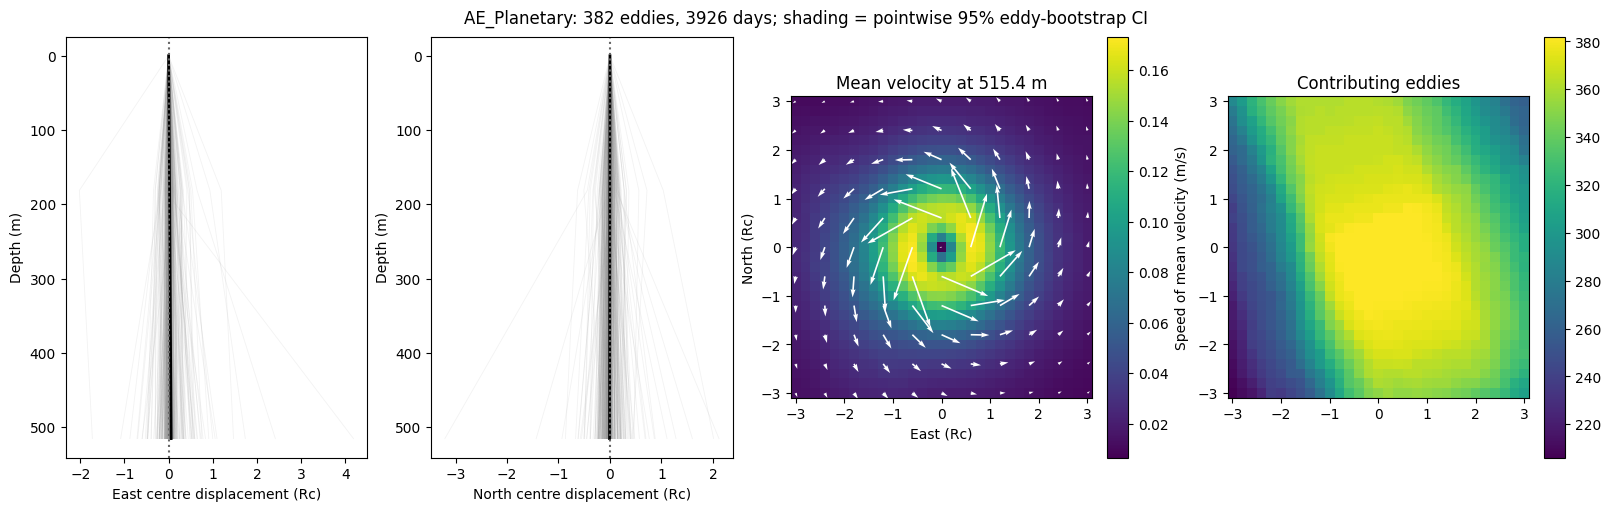

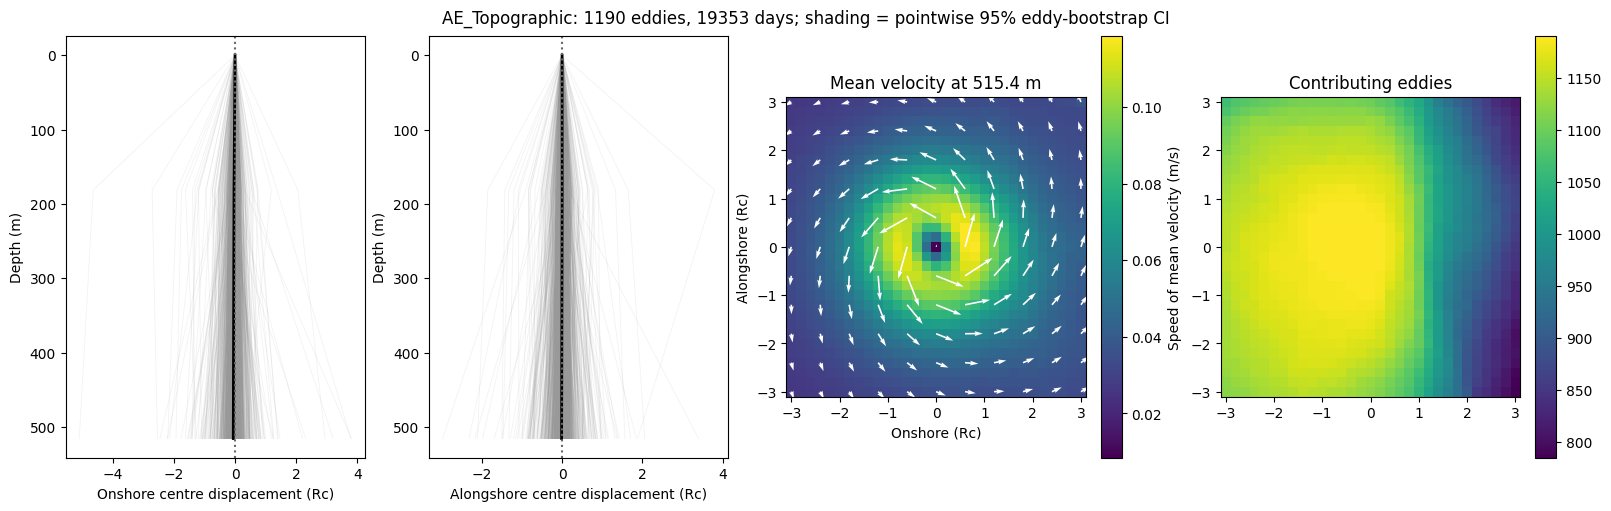

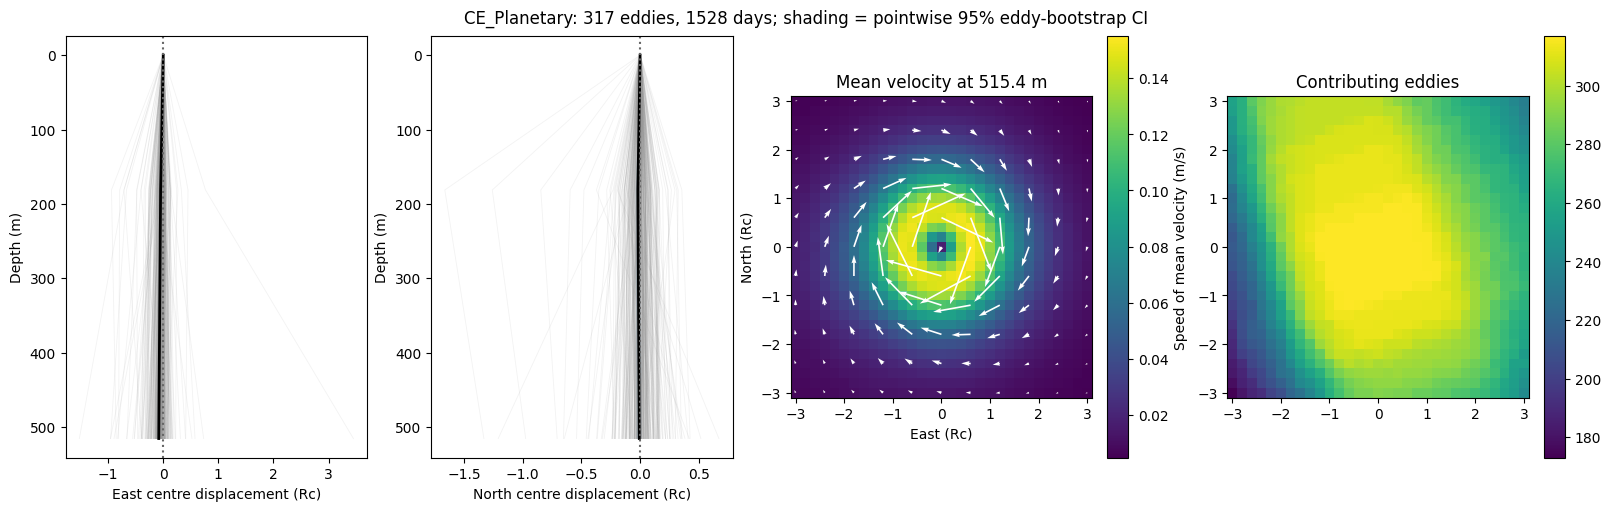

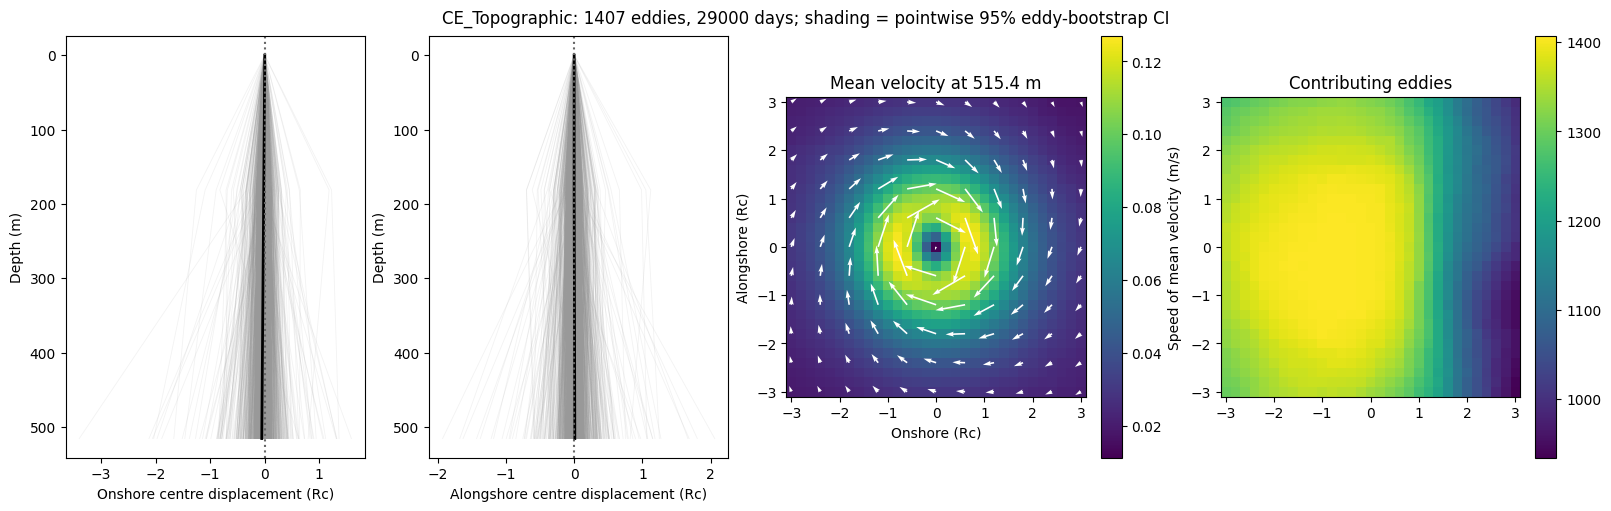

Outputs: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/esp_population_composites/39f937013b2719bf


In [4]:
results = pop.summarise_members(manifest, run/'members', n_boot=config['n_boot'],
                                seed=config['seed'], min_members=config['min_eddies'])
for group, result in results.items():
    arrays = {f'{kind}_{key}':value for kind in ('field','centre') for key,value in result[kind].items()}
    np.savez_compressed(run/f'{group}_summary.npz', **arrays, member_centres=result['members'],
                        depths=depths, coordinate=coordinate)
figures = pop.plot_summary(results, depths, coordinate, config['units'])
for group, fig in figures:
    fig.savefig(run/f'{group}_overview.png', dpi=180)
    plt.show()
print('Outputs:', run)


## Reading the output
Thin grey lines are eddy-mean centrelines; black lines are the eddy-equal mean; shaded bands are pointwise 95% confidence intervals. Deep centres displaced offshore correspond to an onshore deep-to-shallow tilt convention. A small mean offset can coexist with widely spread individual offsets.

Saved summaries include velocity-component means, intervals and support throughout the grid, not just the displayed deepest map. The speed of the mean vector is not mean daily speed. Group means use their own eligible populations, so differences may reflect geography, season, depth selection or radius as well as the named regime.

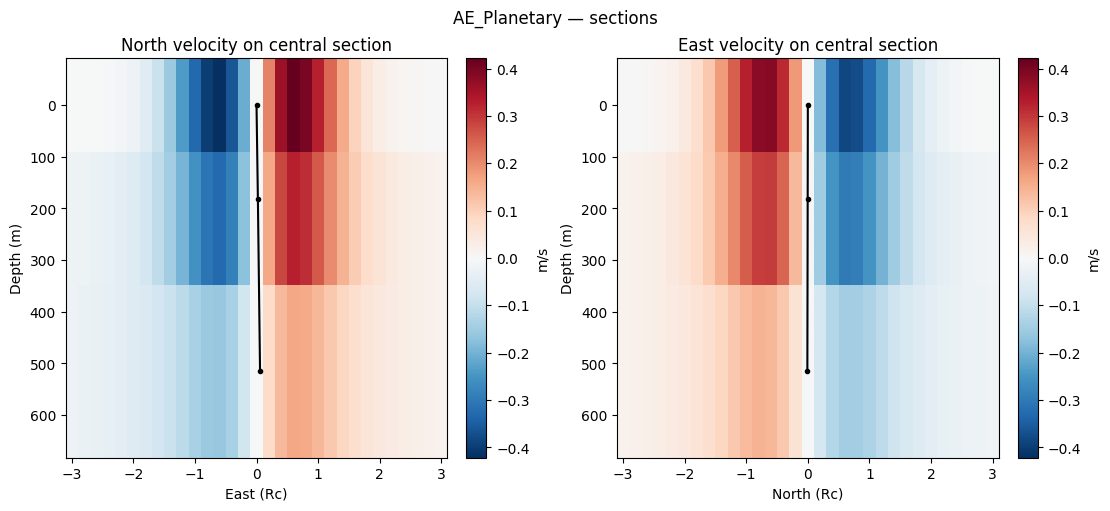

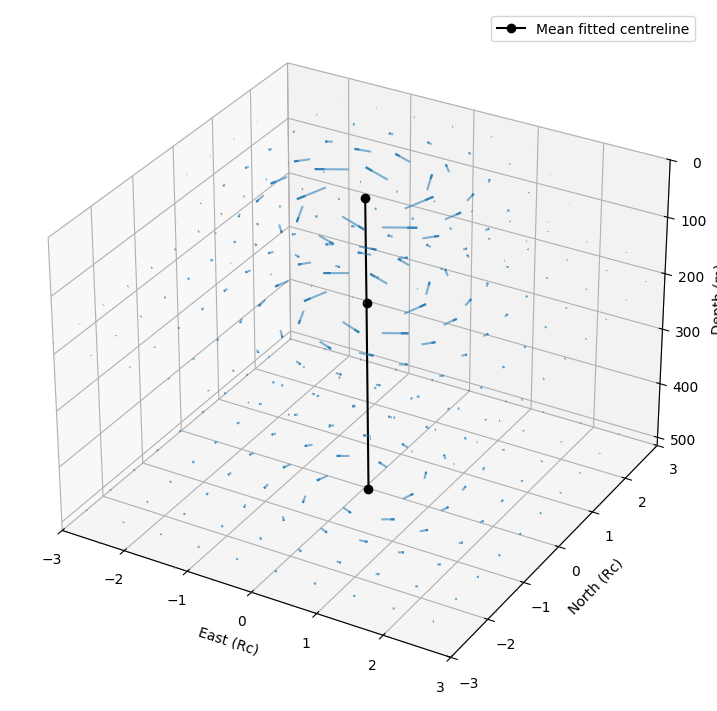

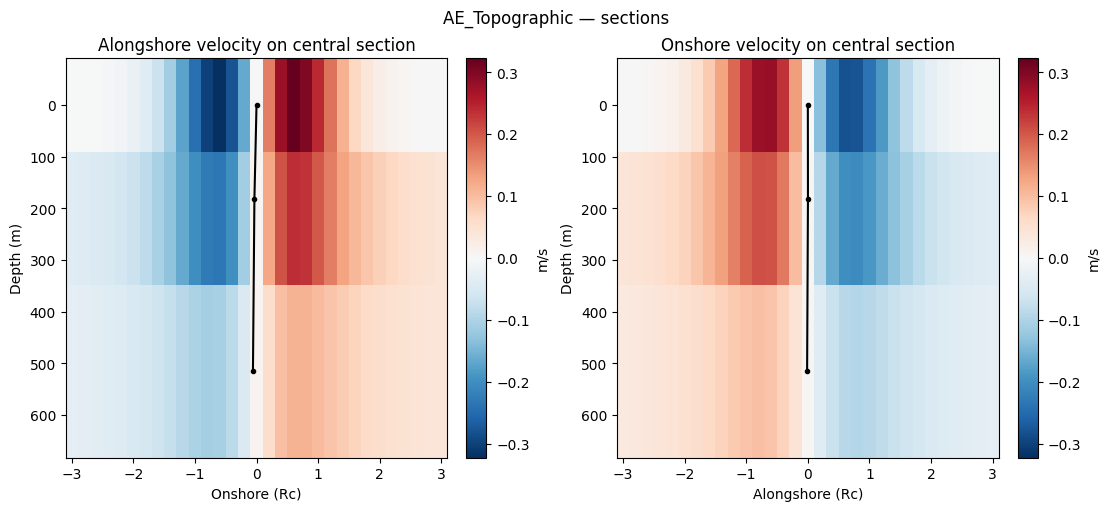

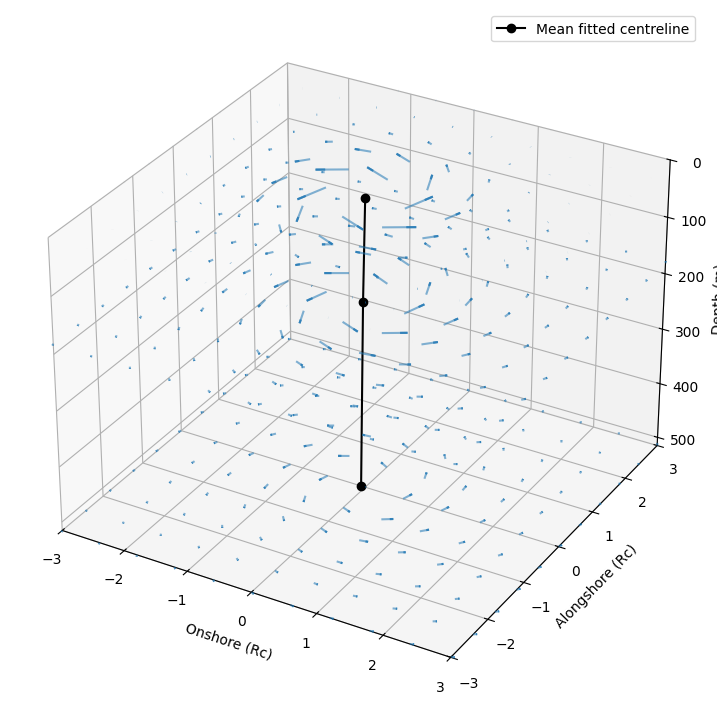

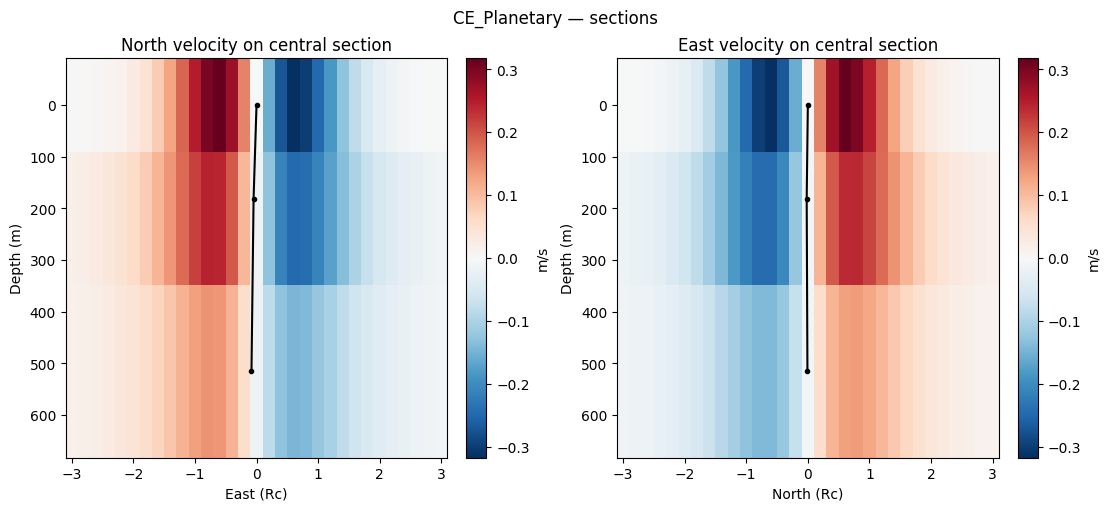

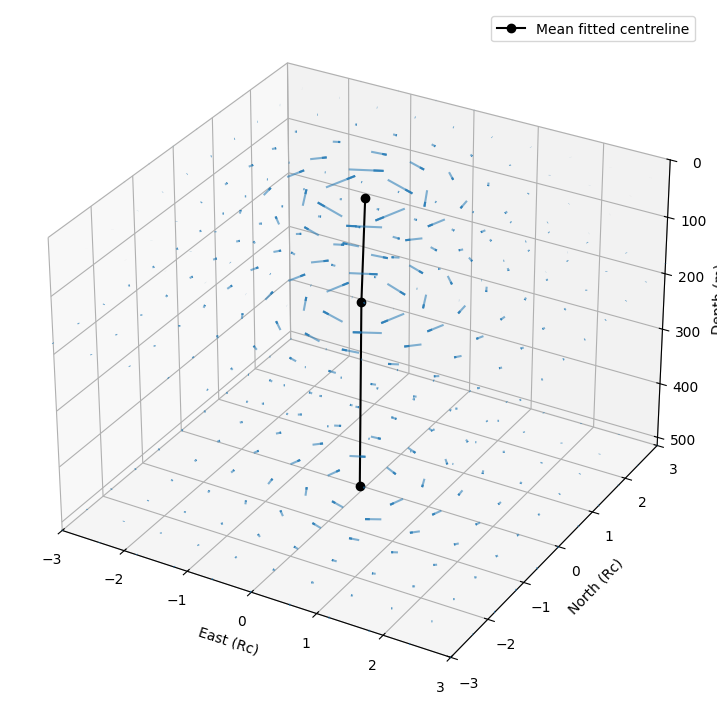

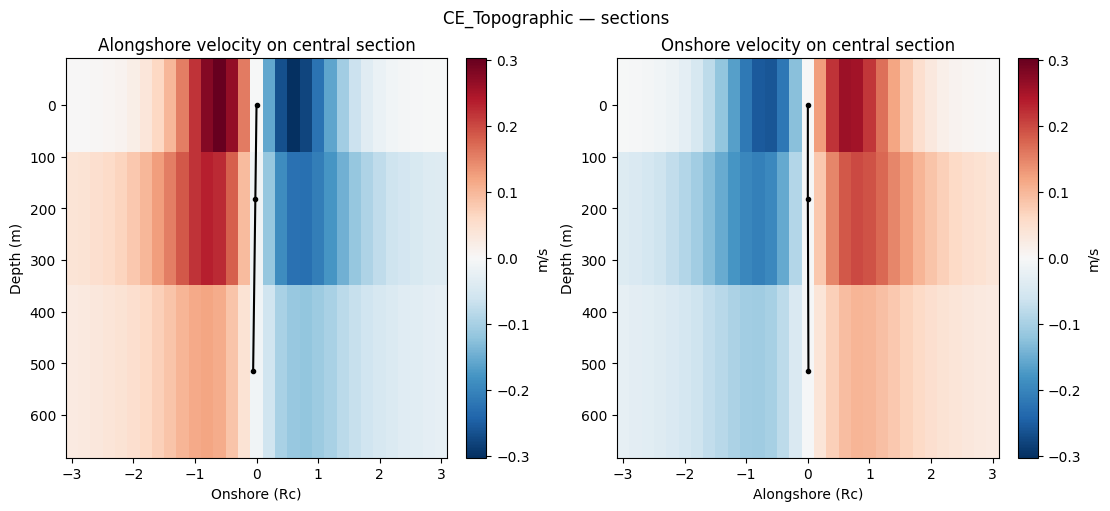

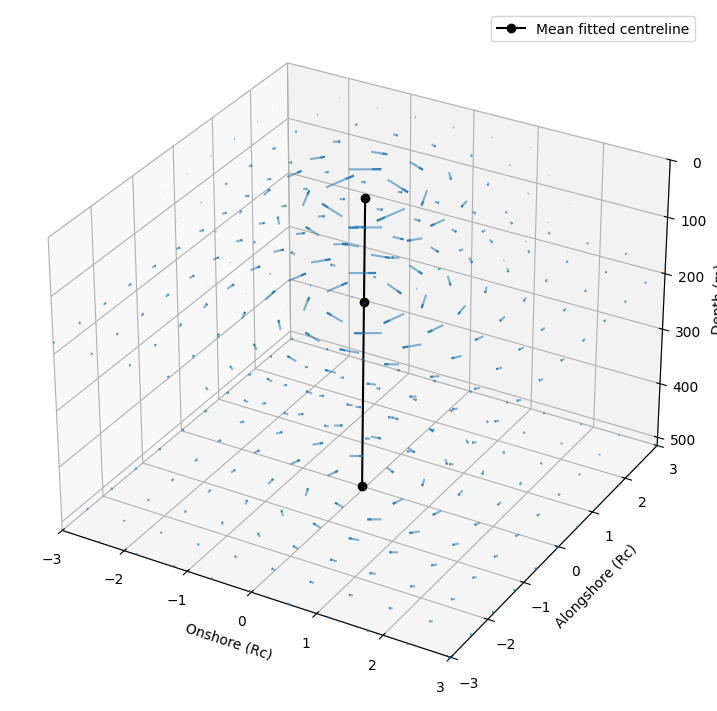

In [5]:
for group, result in results.items():
    for suffix, fig in pop.plot_sections_3d(result, depths, coordinate, config['units']):
        fig.suptitle(group+' — '+suffix)
        fig.savefig(run/f'{group}_{suffix}.png', dpi=180)
        plt.show()
